 **Part-3: Language task**

 **Text Classification with RNN.**

Import Required Libraries

In [1]:
# Data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing libraries
import re
import nltk
!pip install contractions
import contractions

# NLTK libraries
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Deep learning libraries
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.callbacks import EarlyStopping

# Word cloud visualization
from wordcloud import WordCloud

# Word2Vec
!pip install gensim
from gensim.models import Word2Vec

# Save tokenizer
import pickle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 55.3 MB/s eta 0:00:00


Download Required NLTK Packages

In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

Load Dataset

In [3]:
# Load training dataset
train_df = pd.read_csv("/content/drive/MyDrive/AI and Machine Learning/7. Racist Sexist or Not Dataset/train_racisit.csv")

# Load test dataset
test_df = pd.read_csv("/content/drive/MyDrive/AI and Machine Learning/7. Racist Sexist or Not Dataset/test_racisit.csv")

Display Dataset Information

In [4]:
# Display first 5 rows
train_df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [5]:
# Dataset information
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [6]:
# Check missing values
train_df.isnull().sum()

,0
id,0
label,0
tweet,0


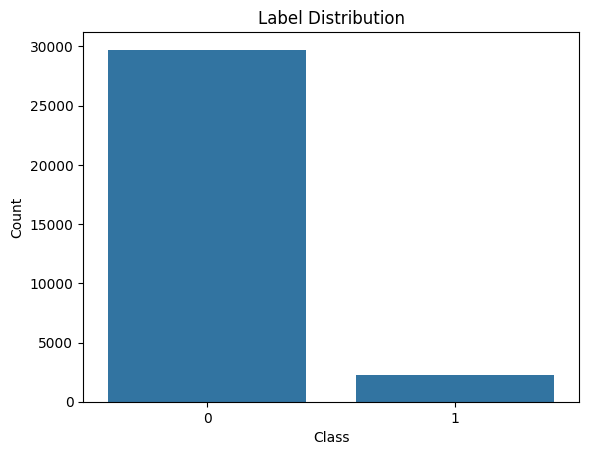

In [7]:
# Visualize class distribution
sns.countplot(x='label', data=train_df)

plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [8]:
# Initialize stopwords
stop_words = set(stopwords.words('english'))

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

Create Text Cleaning Function

In [9]:
# Function for cleaning tweets

def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove mentions and hashtags
    text = re.sub(r"@\w+|#\w+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenize words
    words = word_tokenize(text)

    # Store cleaned words
    cleaned_words = []

    # Remove stopwords and lemmatize
    for word in words:

        if word not in stop_words:

            lemmatized_word = lemmatizer.lemmatize(word)

            cleaned_words.append(lemmatized_word)

    # Join cleaned words
    return " ".join(cleaned_words)

In [10]:
# Apply cleaning function to training tweets
train_df['cleaned_tweet'] = train_df['tweet'].apply(clean_text)

# Apply cleaning function to test tweets
test_df['cleaned_tweet'] = test_df['tweet'].apply(clean_text)

# Display cleaned tweets
train_df[['tweet', 'cleaned_tweet']].head()

,tweet,cleaned_tweet
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunction
1,@user @user thanks for #lyft credit i can't us...,thanks credit use offer wheelchair van pdx
2,bihday your majesty,bihday majesty
3,#model i love u take with u all the time in ...,love take time
4,factsguide: society now #motivation,factsguide society


Word Cloud Visualozation

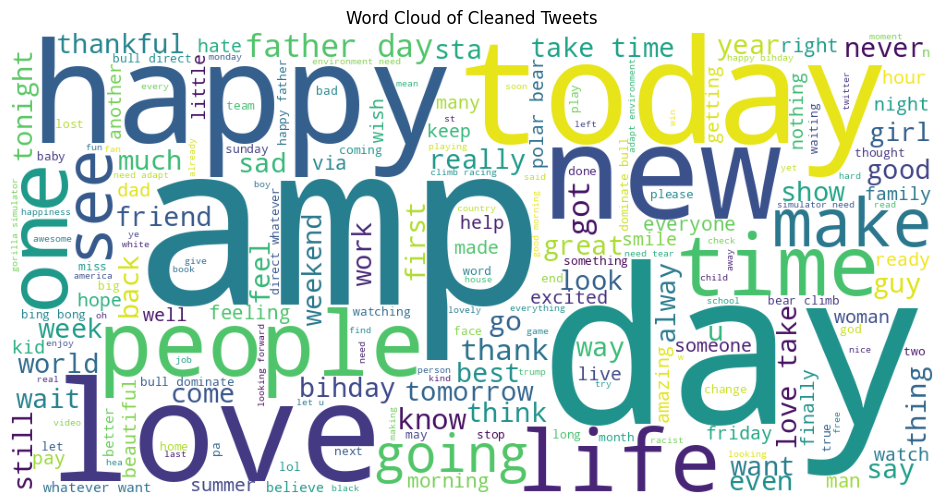

In [11]:
# Combine all cleaned tweets
all_words = " ".join(train_df['cleaned_tweet'])

# Generate word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)

# Display word cloud
plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Word Cloud of Cleaned Tweets")

plt.show()

Most Frequent Words Visualization

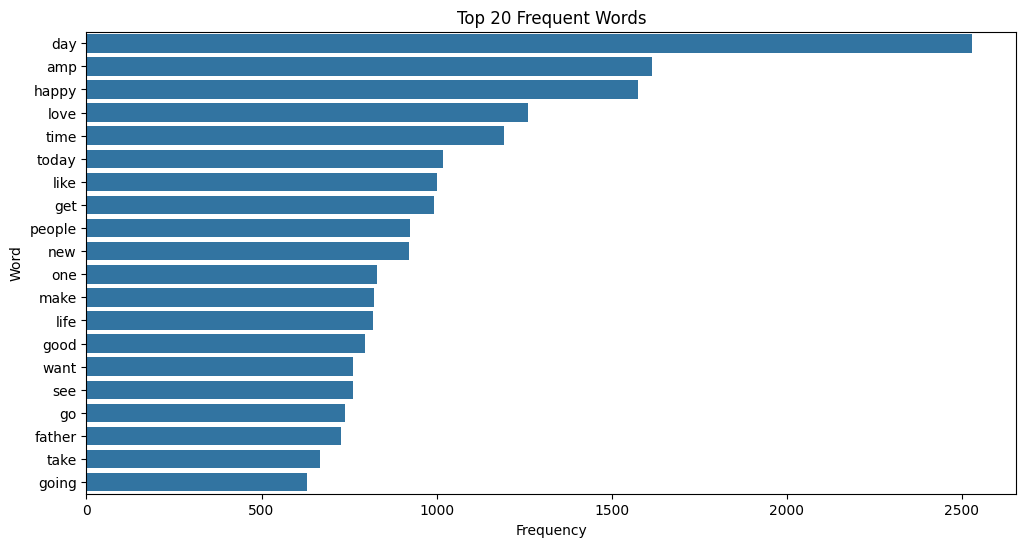

In [12]:
# Split all words
all_word_list = all_words.split()

# Create frequency distribution
freq_dist = nltk.FreqDist(all_word_list)

# Get top 20 frequent words
common_words = freq_dist.most_common(20)

# Convert to DataFrame
freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

# Plot frequent words
plt.figure(figsize=(12,6))

sns.barplot(
    x='Frequency',
    y='Word',
    data=freq_df
)

plt.title("Top 20 Frequent Words")

plt.show()

In [13]:
# Define input features
X = train_df['cleaned_tweet']

# Define target labels
y = train_df['label']

In [14]:
# Split dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Tokenization

In [15]:
# Initialize tokenizer
tokenizer = Tokenizer(
    num_words=10000,
    oov_token='<OOV>'
)

# Fit tokenizer on training data
tokenizer.fit_on_texts(X_train)

In [16]:
# Convert training text into sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)

# Convert validation text into sequences
X_val_seq = tokenizer.texts_to_sequences(X_val)

Percentile-Based Padding

In [17]:
# Calculate sequence lengths
sequence_lengths = [
    len(seq)
    for seq in X_train_seq
]

# Calculate 95th percentile length
max_length = int(
    np.percentile(
        sequence_lengths,
        95
    )
)

print("Max Length:", max_length)

Max Length: 11


Apply Padding

In [18]:
# Pad training sequences
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

# Pad validation sequences
X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_length,
    padding='post'
)

Create Early Stopping Callback

In [19]:
# Prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

Build Model 1 - Simple RNN

In [20]:
# Build Simple RNN model
rnn_model = Sequential()

# Embedding layer
rnn_model.add(
    Embedding(
        input_dim=10000,
        output_dim=128,
        input_length=max_length
    )
)

# Simple RNN layer
rnn_model.add(
    SimpleRNN(64)
)

# Dropout layer
rnn_model.add(Dropout(0.5))

# Output layer
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.build(input_shape=(None, max_length))

# Display model summary
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 11, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

Compile Model 1

In [21]:
# Compile Simple RNN model
rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Train Model 1

In [22]:
# Train Simple RNN model
rnn_history = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.9417 - loss: 0.2004 - val_accuracy: 0.9467 - val_loss: 0.1661
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9684 - loss: 0.0977 - val_accuracy: 0.9357 - val_loss: 0.1766
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9852 - loss: 0.0505 - val_accuracy: 0.9315 - val_loss: 0.2131
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9860 - loss: 0.0472 - val_accuracy: 0.9346 - val_loss: 0.2217


Build Model 2 - LSTM

In [23]:
# Build LSTM model
lstm_model = Sequential()

# Embedding layer
lstm_model.add(
    Embedding(
        input_dim=10000,
        output_dim=128,
        input_length=max_length
    )
)

# Bidirectional LSTM layer
lstm_model.add(
    Bidirectional(
        LSTM(64)
    )
)

# Dropout layer
lstm_model.add(Dropout(0.5))

# Dense hidden layer
lstm_model.add(Dense(64, activation='relu'))

# Output layer
lstm_model.add(Dense(1, activation='sigmoid'))

# Build model manually
lstm_model.build(input_shape=(None, max_length))

# Display model summary
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,137 (5.29 MB)

 Trainable params: 1,387,137 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

Compile Model 2

In [24]:
# Compile LSTM model
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Train Model 2

In [25]:
# Train LSTM model
lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.9436 - loss: 0.1891 - val_accuracy: 0.9474 - val_loss: 0.1589
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - accuracy: 0.9626 - loss: 0.1078 - val_accuracy: 0.9506 - val_loss: 0.1645
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9768 - loss: 0.0702 - val_accuracy: 0.9489 - val_loss: 0.1804
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9844 - loss: 0.0455 - val_accuracy: 0.9442 - val_loss: 0.2635


Train Word2Vec Embeddings

In [26]:
# Tokenize cleaned tweets
word2vec_sentences = [
    text.split()
    for text in train_df['cleaned_tweet']
]

# Train Word2Vec model
word2vec_model = Word2Vec(
    sentences=word2vec_sentences,
    vector_size=100,
    window=5,
    min_count=1
)

Create Embedding Matrix

In [27]:
# Define embedding dimension
embedding_dim = 100

# Create embedding matrix
embedding_matrix = np.zeros(
    (10000, embedding_dim)
)

# Fill embedding matrix
for word, index in tokenizer.word_index.items():

    if index < 10000:

        if word in word2vec_model.wv:

            embedding_matrix[index] = (
                word2vec_model.wv[word]
            )

Build Model 3 - LSTM with Word2Vec

In [28]:
# Build Word2Vec LSTM model
word2vec_lstm_model = Sequential()

# Pretrained embedding layer
word2vec_lstm_model.add(
    Embedding(
        input_dim=10000,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False
    )
)

# LSTM layer
word2vec_lstm_model.add(LSTM(64))

# Dropout layer
word2vec_lstm_model.add(Dropout(0.5))

# Dense hidden layer
word2vec_lstm_model.add(Dense(64, activation='relu'))

# Output layer
word2vec_lstm_model.add(Dense(1, activation='sigmoid'))

# Build model manually
word2vec_lstm_model.build(input_shape=(None, max_length))

# Display model summary
word2vec_lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 11, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,046,465 (3.99 MB)

 Trainable params: 46,465 (181.50 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Compile Model 3

In [29]:
# Compile Word2Vec LSTM model
word2vec_lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Train Model 3

In [30]:
# Train Word2Vec LSTM model
word2vec_history = word2vec_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9300 - loss: 0.2558 - val_accuracy: 0.9309 - val_loss: 0.2432
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9319 - loss: 0.2264 - val_accuracy: 0.9310 - val_loss: 0.2198
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9323 - loss: 0.2193 - val_accuracy: 0.9326 - val_loss: 0.2166


Plot Accuracy Graphs

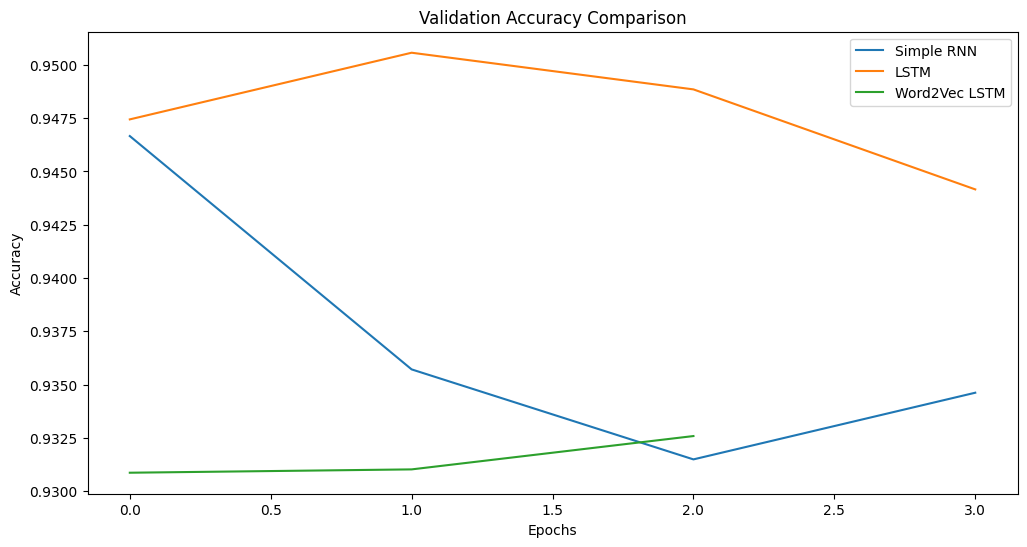

In [31]:
# Plot accuracy comparison
plt.figure(figsize=(12,6))

plt.plot(rnn_history.history['val_accuracy'], label='Simple RNN')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM')
plt.plot(word2vec_history.history['val_accuracy'], label='Word2Vec LSTM')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

Plot Loss Graphs

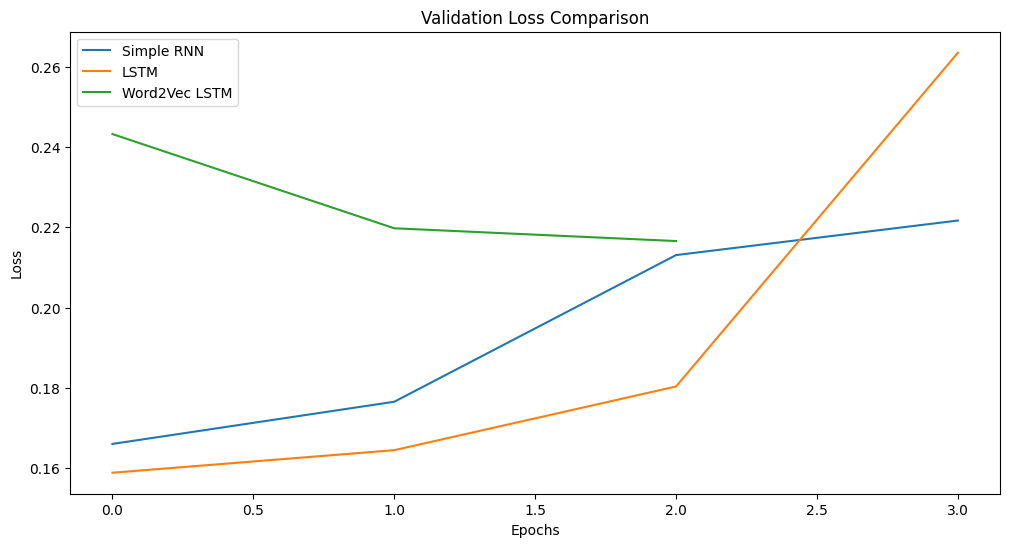

In [32]:
# Plot loss comparison
plt.figure(figsize=(12,6))

plt.plot(rnn_history.history['val_loss'], label='Simple RNN')
plt.plot(lstm_history.history['val_loss'], label='LSTM')
plt.plot(word2vec_history.history['val_loss'], label='Word2Vec LSTM')

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

Evaluate Models

In [33]:
# Evaluate Simple RNN
rnn_loss, rnn_accuracy = rnn_model.evaluate(
    X_val_pad,
    y_val
)

# Evaluate LSTM
lstm_loss, lstm_accuracy = lstm_model.evaluate(
    X_val_pad,
    y_val
)

# Evaluate Word2Vec LSTM
word2vec_loss, word2vec_accuracy = (
    word2vec_lstm_model.evaluate(
        X_val_pad,
        y_val
    )
)

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9467 - loss: 0.1661
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9474 - loss: 0.1589
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9309 - loss: 0.2432


Compare Model Performance

In [34]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': [
        'Simple RNN',
        'LSTM',
        'Word2Vec LSTM'
    ],
    'Accuracy': [
        rnn_accuracy,
        lstm_accuracy,
        word2vec_accuracy
    ],
    'Loss': [
        rnn_loss,
        lstm_loss,
        word2vec_loss
    ]
})

# Display comparison table
comparison_df

,Model,Accuracy,Loss
0,Simple RNN,0.946660,0.166088
1,LSTM,0.947443,0.158919
2,Word2Vec LSTM,0.930862,0.243223


Generate Predictions using Best Model

In [35]:
# Generate predictions
predictions = lstm_model.predict(X_val_pad)

# Convert probabilities into labels
predicted_labels = (
    predictions > 0.5
).astype(int)

200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


Classification Report

In [36]:
# Print classification report
print(classification_report(
    y_val,
    predicted_labels
))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      5937
           1       0.80      0.35      0.49       456

    accuracy                           0.95      6393
   macro avg       0.87      0.67      0.73      6393
weighted avg       0.94      0.95      0.94      6393



Accuracy, Precision, Recall, F1 Score

In [37]:
# Calculate evaluation metrics
accuracy = accuracy_score(
    y_val,
    predicted_labels
)

precision = precision_score(
    y_val,
    predicted_labels
)

recall = recall_score(
    y_val,
    predicted_labels
)

f1 = f1_score(
    y_val,
    predicted_labels
)

# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9474425152510558
Precision: 0.7970297029702971
Recall: 0.3530701754385965
F1 Score: 0.48936170212765956


Confusion Matrix

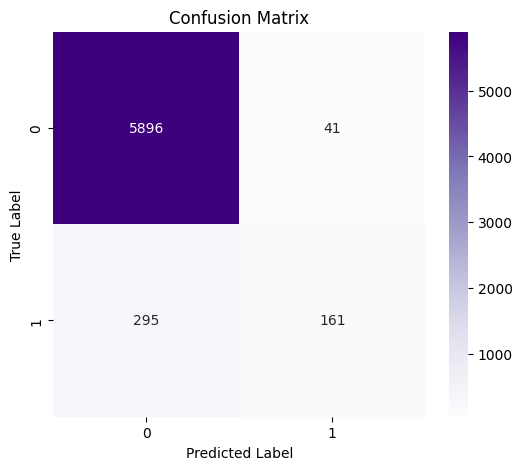

In [38]:
# Generate confusion matrix
cm = confusion_matrix(
    y_val,
    predicted_labels
)

# Plot confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

Error Analysis

In [39]:
# Find incorrect predictions
incorrect_indices = np.where(
    predicted_labels.flatten() != y_val.values
)[0]

# Display incorrect predictions
for i in incorrect_indices[:3]:

    print("Tweet:")
    print(X_val.iloc[i])

    print("\nActual Label:", y_val.iloc[i])

    print("Predicted Label:", predicted_labels[i][0])

    print("\n-------------------------\n")

Tweet:
kind people need erased eahs surface

Actual Label: 1
Predicted Label: 0

-------------------------

Tweet:
sick liberal thinking ok dictate think israeli jew allowed live including isr

Actual Label: 1
Predicted Label: 0

-------------------------

Tweet:
uk fell pop star job

Actual Label: 1
Predicted Label: 0

-------------------------



Error Analysis Discussion

Possible reasons for errors:

1. Sarcasm and irony are difficult to detect.
2. Tweets may contain ambiguous language.
3. Informal slang and abbreviations reduce accuracy.
4. Limited dataset size affects generalization.
5. Contextual meaning may be missing.

Save Model and Tokenizer

In [40]:
# Save trained model
lstm_model.save(
    'racist_sexist_detection_model.keras'
)

print("Model saved successfully!")

Model saved successfully!


In [41]:
# Save tokenizer
with open('tokenizer.pkl', 'wb') as f:

    pickle.dump(tokenizer, f)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


Custom Tweet Prediction Function

In [42]:
# Function for custom prediction

def predict_tweet(tweet):

    # Clean tweet
    cleaned = clean_text(tweet)

    # Convert to sequence
    sequence = tokenizer.texts_to_sequences([
        cleaned
    ])

    # Pad sequence
    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post'
    )

    # Predict
    prediction = lstm_model.predict(
        padded,
        verbose=0
    )

    # Display result
    if prediction[0][0] > 0.5:

        print("Racist/Sexist Tweet")

    else:

        print("Non-Hateful Tweet")

Test Custom Tweets

In [43]:
# Example predictions
predict_tweet("I hate all women")

predict_tweet("Have a wonderful day everyone")

Racist/Sexist Tweet
Non-Hateful Tweet


GUI Implementation using Streamlit

In [44]:
 # Save this code in app.py
!pip install streamlit

import streamlit as st

st.title("Racist/Sexist Tweet Detector")

# Input box
user_input = st.text_area(
    "Enter Tweet"
)

# Predict button
if st.button("Predict"):

    # Clean text
    cleaned = clean_text(user_input)

    # Convert to sequence
    sequence = tokenizer.texts_to_sequences([
        cleaned
    ])

    # Apply padding
    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post'
    )
    # Predict result
    prediction = lstm_model.predict(
        padded
    )

    # Display prediction
    if prediction[0][0] > 0.5:

        st.error(
            "Racist/Sexist Tweet"
        )

    else:

        st.success(
            "Non-Hateful Tweet"
        )


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 67.1 MB/s eta 0:00:00


2026-05-08 05:35:22.767 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 05:35:23.170 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-08 05:35:23.171 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 05:35:23.173 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 05:35:23.174 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 05:35:23.176 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 05:35:23.177 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 05:35:23.178 Thread 'MainThread': mi

In [48]:
%%writefile app.py

import streamlit as st
import re
import contractions
import nltk
import pickle

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Download nltk resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Load trained model
model = load_model(
    'racist_sexist_detection_model.keras'
)

# Load tokenizer
with open('tokenizer.pkl', 'rb') as f:

    tokenizer = pickle.load(f)

# Max sequence length
max_length = 50

# Text cleaning function
def clean_text(text):

    text = text.lower()

    text = contractions.fix(text)

    text = re.sub(r"http\\S+", "", text)

    text = re.sub(r"@\\w+|#\\w+", "", text)

    text = re.sub(r"\\d+", "", text)

    text = re.sub(r"[^a-zA-Z\\s]", "", text)

    words = word_tokenize(text)

    cleaned_words = []

    for word in words:

        if word not in stop_words:

            lemmatized_word = lemmatizer.lemmatize(word)

            cleaned_words.append(lemmatized_word)

    return " ".join(cleaned_words)

# Streamlit title
st.title("Racist/Sexist Tweet Detector")

# Input box
user_input = st.text_area(
    "Enter Tweet"
)

# Predict button
if st.button("Predict"):

    cleaned = clean_text(user_input)

    sequence = tokenizer.texts_to_sequences(
        [cleaned]
    )

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post'
    )

    prediction = model.predict(padded)

    if prediction[0][0] > 0.5:

        st.error(
            "Racist/Sexist Tweet"
        )

    else:

        st.success(
            "Non-Hateful Tweet"
        )

Overwriting app.py


In [49]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋2026-05-08 05:52:22.819 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.224.89.157:8501

your url is: https://witty-bugs-wash.loca.lt
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
2026-05-08 05:54:34.928938: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nl

# Conclusion:

The project successfully implemented three deep learning
models for text classification:

1. Simple RNN
2. LSTM
3. Word2Vec LSTM

Among the models, LSTM achieved better performance
because it captures long-term dependencies in text.

Word2Vec embeddings improved semantic understanding of words and enhanced contextual learning.

The models effectively classified racist and sexist tweets from non-hateful tweets.